# Hyperparamater Tuning




### At some point while doing comments I coverted  a Python panel to java by accident. It the process of trying to fix it I cleared all the outputs by accident some of the number in my conclusion may no longer match up with the live data it is currenlty 30mins to submission
This one seems ok at time of submission. I have revertedsome comments though
The DLb.ipynb in the same folder runs through.

---
#### Imports 
Import neccessary components.

---

In [1]:
# Import necessary libraries.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import keras_tuner as kt
import tensorflow as tf
import tensorflow.keras.backend as K
import os
import random
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
LabelEncoder

from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop, Adadelta
from tensorflow.keras.layers import Input, Dense , Dropout
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LeakyReLU
from IPython.display import Markdown, display
from sklearn.metrics import r2_score

!pip install tabulate

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\NedMatheson\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## Data Preprocessing

1. Load Dataset
1. Remove Invalid Column
1. Test Train Validation split
1. Scale the data to aid neural network performance

---

In [2]:
# Load the dataset from the CSV file into a pandas DataFrame.
#d = pd.read_csv("../Data/NZ_LUCAS_SMAP_NIWA.csv")
df= pd.read_csv("C:\\Python\\COMP661 Deep Learning\\Comp661_Assigment1\\1174976_EcoVision_Project1\\Data\\NZ_LUCAS_SMAP_NIWA.csv")
# Drop the unnecessary column '36' from the dataframe.
df.drop(columns=['36'], inplace=True)

# Target
y = df["soil_organic_carbon_target"]

# Features (Drop soil_organic_carbon_target from the features)
X = df.drop(columns=["soil_organic_carbon_target"])


# Train (70%) / Temp (30%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Validation (15%) / Test (15%)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Scale the data to aid neural network training.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)


#Verify the shapes of the training, validation, and test sets, as well as the mean and standard deviation of the scaled training set.
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print('X_train_scaled mean:', X_train_scaled.mean())
print('X_train_scaled standard deviation:', X_train_scaled.std())

Training set: (3500, 35)
Validation set: (750, 35)
Test set: (750, 35)
X_train_scaled mean: -5.977259503679863e-17
X_train_scaled standard deviation: 1.0


---
### Create Baseline Model

#### Compile the model using:

* Loss Function: Mean Squared Error (MSE)
* Optimizer: Adam (default learning rate)
* Evaluation Metric: Mean Absolute Error (MAE)

#### Train the model using:


* Epochs: 100
* Batch size: 32
* Validation set: created in Part 1

---

In [3]:


# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
epoch_num = 100

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        32,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ),
    tf.keras.layers.Dense(1)
])

baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=epoch_num,
    batch_size=32,
    verbose=1
)

Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3811.3845 - mae: 60.9778 - val_loss: 3582.2793 - val_mae: 59.0345
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3329.8606 - mae: 56.9114 - val_loss: 2998.5779 - val_mae: 53.9210
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2666.4702 - mae: 50.7875 - val_loss: 2262.3647 - val_mae: 46.6698
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1911.9606 - mae: 42.7257 - val_loss: 1511.0369 - val_mae: 37.7693
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1215.6588 - mae: 33.4789 - val_loss: 894.5664 - val_mae: 28.2662
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 698.3515 - mae: 24.3974 - val_loss: 494.4511 - val_mae: 20.0280
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 393.2892 - mae: 17.4446 - val_loss: 291.0634 - val_mae: 14.6969
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 248.4693 - mae: 13.4049 - val_loss: 206.0557 - val_mae: 11.9497
Epo

---
### Evaluate baseline model

---

In [4]:
test_loss, test_mae = baseline_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 23.877609252929688
Test MAE: 3.9056928157806396


---
### Training History Plot, Baseline Model

Training vs Validation loss 

---

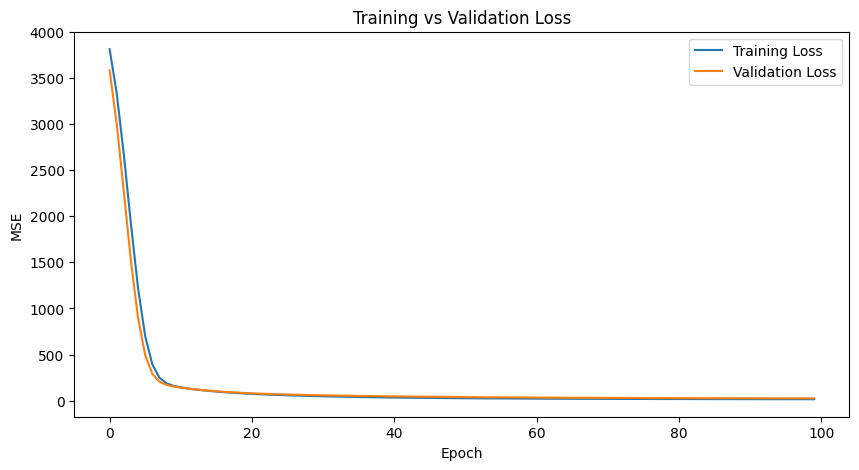

In [5]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

---
#### Create Resuable Function

Now Works with Leaky_Relu

---

In [6]:

# Create Reusable Function to Create Dynamic Model.

def create_dynamic_model(num_hidden_layers,
                         num_neurons,
                         activation_choice,
                         optimizer_choice):

    model = Sequential()

    # First hidden layer added for leaky_relu
    if activation_choice == 'leaky_relu':
        model.add(Dense(num_neurons, input_shape=(X_train_scaled.shape[1],)))
        model.add(LeakyReLU(negative_slope=0.01))
    else:
        model.add(Dense(num_neurons,
                        activation=activation_choice,
                        input_shape=(X_train_scaled.shape[1],)))

    # Remaining hidden layers
    for _ in range(num_hidden_layers - 1):

        if activation_choice == 'leaky_relu':
            model.add(Dense(num_neurons))
            model.add(LeakyReLU(negative_slope=0.01))
        else:
            model.add(Dense(num_neurons,
                            activation=activation_choice))

    # Output layer for regression
    model.add(Dense(1))

    model.compile(
        optimizer=optimizer_choice,
        loss='mse',
        metrics=['mae']
    )

    return model


#Before I break things with LeakyReLU
""""
def create_dynamic_model(
    num_hidden_layers,
    num_neurons,
    activation_choice,
    optimizer_choice
):

    model = tf.keras.Sequential()

    model.add(
        tf.keras.layers.Input(
            shape=(X_train_scaled.shape[1],)
        )
    )

    for _ in range(num_hidden_layers):
        model.add(
            tf.keras.layers.Dense(
                num_neurons,
                activation=activation_choice
            )
        )

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=optimizer_choice,
        loss='mse',
        metrics=['mae']
    )

    return model
"""

'"\ndef create_dynamic_model(\n    num_hidden_layers,\n    num_neurons,\n    activation_choice,\n    optimizer_choice\n):\n\n    model = tf.keras.Sequential()\n\n    model.add(\n        tf.keras.layers.Input(\n            shape=(X_train_scaled.shape[1],)\n        )\n    )\n\n    for _ in range(num_hidden_layers):\n        model.add(\n            tf.keras.layers.Dense(\n                num_neurons,\n                activation=activation_choice\n            )\n        )\n\n    model.add(tf.keras.layers.Dense(1))\n\n    model.compile(\n        optimizer=optimizer_choice,\n        loss=\'mse\',\n        metrics=[\'mae\']\n    )\n\n    return model\n'

In [7]:

#Test Super loop I was diverted by


#Arrays for testing loop to be commented out for final submission
#hidden_layers = [1, 2]
#num_neurons = [8, 16]
#activation_array = ['relu', 'tanh']
#optimizer_choice = ['adam', 'sgd']
"""""
for h in hidden_layers:
    print(f"Training model with {h} hidden layers...")
    for n in num_neurons:
        print(f"Number of neurons: {n}")
    for a in activation_array:
        print(f"Activation function: {a}")
    for o in optimizer_choice:
        print(f"Optimizer: {o}")
        model = create_dynamic_model(num_hidden_layers=h , num_neurons=n, activation_choice=a, optimizer_choice=o)
        
        history = model.fit(
            X_train_scaled,
            y_train,
            validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        verbose=1
    )
    
    test_loss, test_mae = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )
    
    print(f"Test MSE for {h} hidden layers: {test_loss}")
    print(f"Test MAE for {h} hidden layers: {test_mae}")
    
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {h} Hidden Layers")
    plt.legend()
    
    plt.show()

    """


'""\nfor h in hidden_layers:\n    print(f"Training model with {h} hidden layers...")\n    for n in num_neurons:\n        print(f"Number of neurons: {n}")\n    for a in activation_array:\n        print(f"Activation function: {a}")\n    for o in optimizer_choice:\n        print(f"Optimizer: {o}")\n        model = create_dynamic_model(num_hidden_layers=h , num_neurons=n, activation_choice=a, optimizer_choice=o)\n\n        history = model.fit(\n            X_train_scaled,\n            y_train,\n            validation_data=(X_val_scaled, y_val),\n        epochs=100,\n        batch_size=32,\n        verbose=1\n    )\n\n    test_loss, test_mae = model.evaluate(\n        X_test_scaled,\n        y_test,\n        verbose=0\n    )\n\n    print(f"Test MSE for {h} hidden layers: {test_loss}")\n    print(f"Test MAE for {h} hidden layers: {test_mae}")\n\n    plt.figure(figsize=(10,5))\n\n    plt.plot(history.history[\'loss\'], label=\'Training Loss\')\n    plt.plot(history.history[\'val_loss\'], labe

---
### Hidden Layer Loop



Loop through the hidden layers 1-4 with the same number of neurons (32), activation_choice (relu ) and optimizer_choice (adam)

---

Training model with 1 hidden layers...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3802.6772 - mae: 60.9118 - val_loss: 3584.8247 - val_mae: 59.0630
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3346.4685 - mae: 57.0647 - val_loss: 3027.7759 - val_mae: 54.2044
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2695.4688 - mae: 51.1100 - val_loss: 2284.5515 - val_mae: 46.9692
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1913.9452 - mae: 42.8603 - val_loss: 1496.5815 - val_mae: 37.7142
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1181.4596 - mae: 33.1552 - val_loss: 857.6649 - val_mae: 27.7388
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 655.3694 - mae: 23.6710 - val_loss: 463.9503 - val_mae: 19.2754
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 362.5617 - mae: 16.6116 - val_loss: 277.0520 - val_mae: 14.1791
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 230.9220 - mae: 12.8479 - val_loss: 204.0706 - val_mae: 11.8602
Epo

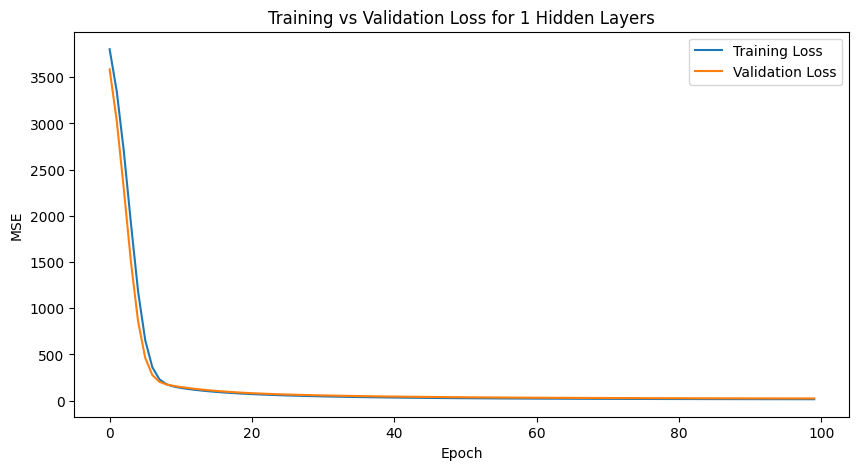

Training model with 2 hidden layers...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3256.8359 - mae: 56.0157 - val_loss: 1980.6942 - val_mae: 43.2861
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 747.6920 - mae: 23.3329 - val_loss: 176.8792 - val_mae: 10.8528
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 138.6835 - mae: 9.4237 - val_loss: 134.9299 - val_mae: 9.3528
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109.1224 - mae: 8.3610 - val_loss: 116.8980 - val_mae: 8.7103
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 93.6607 - mae: 7.7584 - val_loss: 104.4972 - val_mae: 8.2404
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 82.8413 - mae: 7.2955 - val_loss: 95.2600 - val_mae: 7.8737
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 74.6750 - mae: 6.9330 - val_loss: 88.0862 - val_mae: 7.5770
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 68.2103 - mae: 6.6258 - val_loss: 82.3479 - val_mae: 7.3341
Epoch 9/100
110/110 ━━━━━━━━━

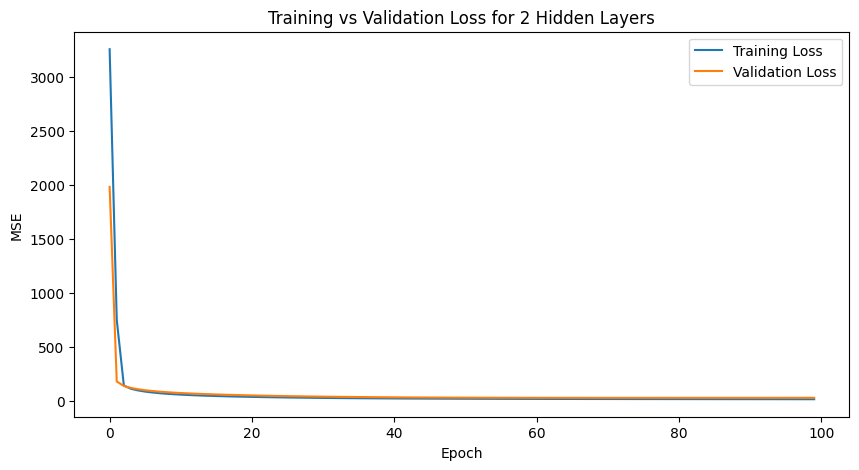

Training model with 3 hidden layers...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2815.8164 - mae: 49.9821 - val_loss: 263.2510 - val_mae: 13.2695
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 146.8711 - mae: 9.6840 - val_loss: 117.7527 - val_mae: 8.7106
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 98.5511 - mae: 7.9279 - val_loss: 99.8157 - val_mae: 8.0141
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 82.3723 - mae: 7.2354 - val_loss: 87.9697 - val_mae: 7.5186
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 71.1772 - mae: 6.7261 - val_loss: 79.2018 - val_mae: 7.1328
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 62.8535 - mae: 6.3201 - val_loss: 72.5276 - val_mae: 6.8293
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56.4270 - mae: 5.9899 - val_loss: 67.1349 - val_mae: 6.5652
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 51.2698 - mae: 5.7094 - val_loss: 62.7065 - val_mae: 6.3375
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━

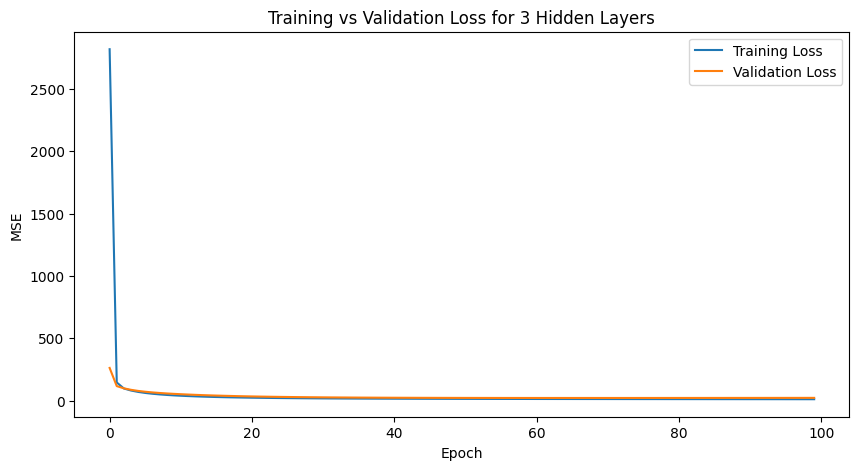

Training model with 4 hidden layers...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2185.2607 - mae: 40.5762 - val_loss: 165.4547 - val_mae: 10.3171
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 123.7029 - mae: 8.8465 - val_loss: 105.7897 - val_mae: 8.1747
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 92.5029 - mae: 7.6749 - val_loss: 92.0129 - val_mae: 7.5888
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 78.2698 - mae: 7.0547 - val_loss: 82.1518 - val_mae: 7.1409
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 68.2221 - mae: 6.5802 - val_loss: 74.6277 - val_mae: 6.7818
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 60.6668 - mae: 6.2068 - val_loss: 68.6602 - val_mae: 6.4814
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54.6433 - mae: 5.8918 - val_loss: 63.7861 - val_mae: 6.2389
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49.6886 - mae: 5.6219 - val_loss: 59.6956 - val_mae: 6.0267
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━

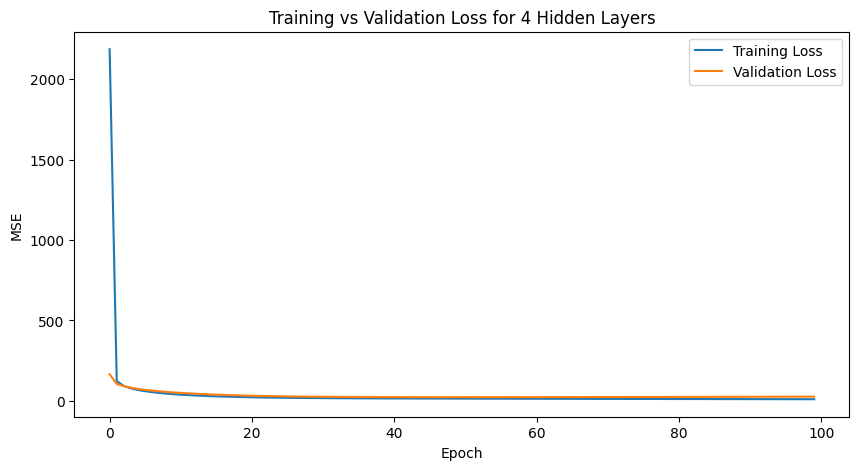


### Results for different hidden layers

|   Variable |   Validation MSE |   Validation MAE |
|-----------:|-----------------:|-----------------:|
|          1 |          24.695  |          3.92399 |
|          2 |          25.3775 |          4.01645 |
|          3 |          23.4686 |          3.81396 |
|          4 |          26.9562 |          4.06521 |

3 hidden layers had the best results with the lowest validation MSE of 23.468645 and validation MAE of 3.813957.


In [8]:
# Zero results

results = []

# Dataframe to store all results from each hyperparameter combination.
results_total =  pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)

# Hidden layers loop
# Hidden layers array for the loop
hidden_layers = [1, 2, 3, 4]
# Data Frame to store results for the current hyperparameter being testeds
results_df=  pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)

# Help with the results dataframe, clear it before starting the loop to avoid appending to old results.
results_df = results_df.iloc[0:0]
results_df.loc[len(results_df)] = ['Hidden Layers Depth', '', '']


# Start the loop to train models with different numbers of hidden layers and record their performance.
for h in hidden_layers:
    print(f"Training model with {h} hidden layers...")
    model = create_dynamic_model(num_hidden_layers=h , num_neurons=32, activation_choice='relu', optimizer_choice='adam')
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        #epochs=5,
        batch_size=32,
        verbose=1
    )

    val_loss, val_mae = model.evaluate(
        X_val_scaled, 
        y_val, 
        verbose=0
    )
    # Print the validation MSE and MAE for the current number of hidden layers.
    print(f"Validation MSE for {h} hidden layers: {val_loss}")
    print(f"Validation MAE for {h} hidden layers: {val_mae}")

    # Plot the training and validation loss for the current number of hidden layers.
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {h} Hidden Layers")
    plt.legend()
    plt.show()
    # Add row to results dataframe
    results_df.loc[len(results_df)] = [h, val_loss, val_mae]
    #End of loop for hidden layers.

# Add current results to the total results dataframe.
results_total =pd.concat([results_total, results_df], ignore_index=True)

#print("Results for different hidden layers:")
#print(results_df)

# Print the table of results for differnent hidden layers in markup.
from IPython.display import Markdown, display

# Ignore the title row
numeric_rows = results_df[
    pd.to_numeric(
        results_df["Validation MSE"],
        errors="coerce"
    ).notna()
]

best_row = numeric_rows.loc[
    numeric_rows["Validation MSE"].idxmin()
]

markdown_text = f"""
### Results for different hidden layers

{numeric_rows.to_markdown(index=False)}

{int(best_row['Variable'])} hidden layers had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))


# Assigen the depth_winner variable.
depth_winner = int(
    numeric_rows.loc[
        numeric_rows["Validation MSE"].idxmin(),
        "Variable"
    ]
)

---

The Hidden Layer Winner will be passed forward.

---

---
### Number of Neurons Loop

---

Training model with 8 number of neurons...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3827.1406 - mae: 61.0949 - val_loss: 3568.1421 - val_mae: 58.8485
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2872.0408 - mae: 52.2124 - val_loss: 1790.9557 - val_mae: 40.0034
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 846.7556 - mae: 24.7942 - val_loss: 390.5618 - val_mae: 16.0177
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 305.1217 - mae: 14.0911 - val_loss: 257.1940 - val_mae: 13.1151
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 223.7146 - mae: 12.0743 - val_loss: 208.1254 - val_mae: 11.8536
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 186.5780 - mae: 11.0210 - val_loss: 182.4555 - val_mae: 11.0600
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 164.0249 - mae: 10.3177 - val_loss: 164.5685 - val_mae: 10.4921
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 147.1595 - mae: 9.7601 - val_loss: 150.1379 - val_mae: 10.0306
Epoch 9/1

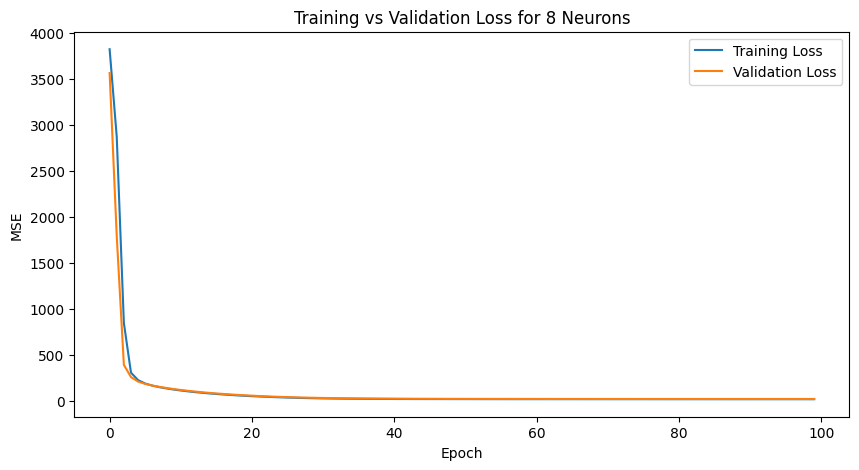

Training model with 16 number of neurons...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3992.5820 - mae: 62.4541 - val_loss: 3685.5823 - val_mae: 59.9214
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2251.5374 - mae: 44.3702 - val_loss: 459.6815 - val_mae: 17.9961
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 246.8939 - mae: 12.5687 - val_loss: 177.7593 - val_mae: 10.8497
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 154.1913 - mae: 9.9103 - val_loss: 141.5712 - val_mae: 9.6723
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 125.5547 - mae: 8.9330 - val_loss: 123.0674 - val_mae: 8.9793
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 107.6965 - mae: 8.2668 - val_loss: 110.2810 - val_mae: 8.4922
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 94.6056 - mae: 7.7357 - val_loss: 100.6605 - val_mae: 8.0969
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 84.5591 - mae: 7.3042 - val_loss: 92.8882 - val_mae: 7.7514
Epoch 9/100
110/110 ━━

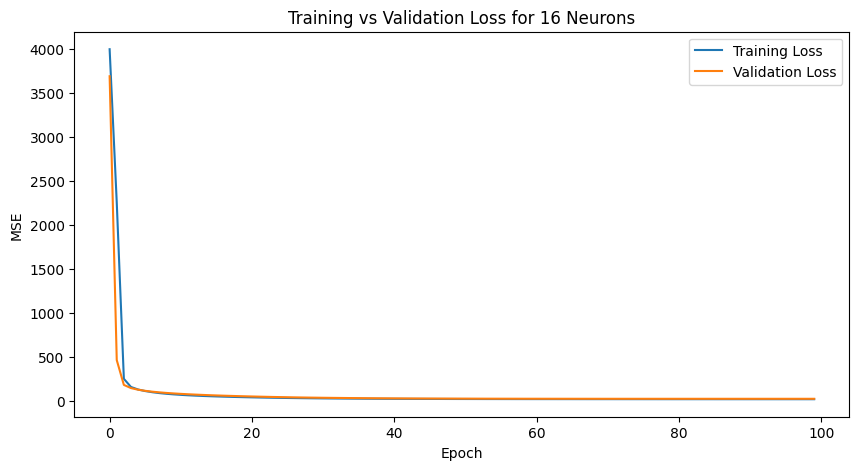

Training model with 32 number of neurons...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2746.7520 - mae: 49.1970 - val_loss: 238.5492 - val_mae: 12.6264
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 142.3078 - mae: 9.5048 - val_loss: 110.4980 - val_mae: 8.3452
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 95.5540 - mae: 7.8299 - val_loss: 97.3553 - val_mae: 7.8290
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 82.2025 - mae: 7.2596 - val_loss: 87.9216 - val_mae: 7.4442
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 72.5534 - mae: 6.8122 - val_loss: 80.4473 - val_mae: 7.1413
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 65.0210 - mae: 6.4428 - val_loss: 74.2291 - val_mae: 6.8820
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 58.9677 - mae: 6.1303 - val_loss: 68.9564 - val_mae: 6.6527
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53.9202 - mae: 5.8597 - val_loss: 64.4906 - val_mae: 6.4505
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━

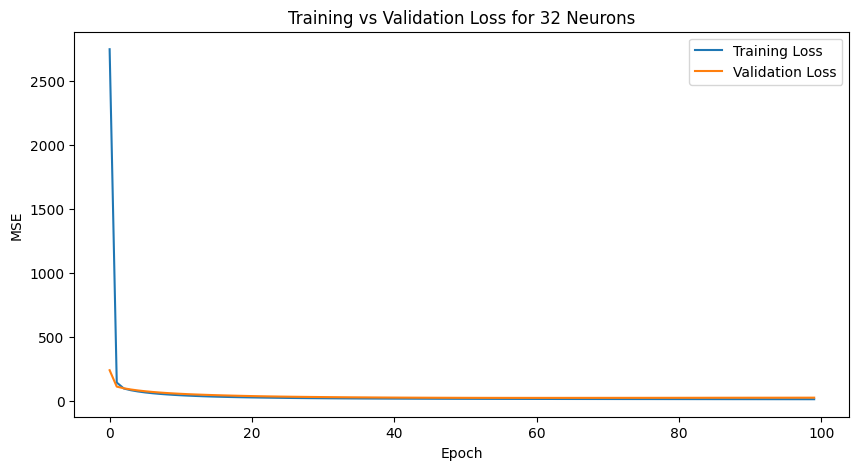

Training model with 64 number of neurons...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1419.8413 - mae: 29.7458 - val_loss: 121.0198 - val_mae: 8.8064
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 92.5981 - mae: 7.7388 - val_loss: 99.2804 - val_mae: 7.9930
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 74.4443 - mae: 6.9294 - val_loss: 86.9340 - val_mae: 7.5035
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63.0542 - mae: 6.3689 - val_loss: 78.4157 - val_mae: 7.1534
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55.0129 - mae: 5.9386 - val_loss: 71.9168 - val_mae: 6.8555
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49.0443 - mae: 5.5992 - val_loss: 66.6413 - val_mae: 6.6072
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44.4143 - mae: 5.3235 - val_loss: 62.3326 - val_mae: 6.4008
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40.7069 - mae: 5.0933 - val_loss: 58.7587 - val_mae: 6.2129
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━

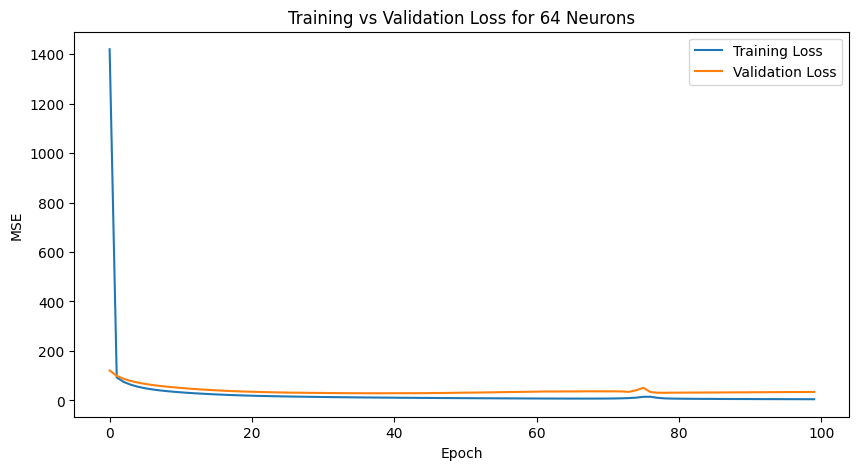

Training model with 128 number of neurons...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1072.6440 - mae: 23.5882 - val_loss: 94.1861 - val_mae: 7.7549
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 74.6817 - mae: 6.9033 - val_loss: 79.7776 - val_mae: 7.1554
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 61.3050 - mae: 6.2505 - val_loss: 71.7270 - val_mae: 6.8046
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53.0450 - mae: 5.8221 - val_loss: 66.2337 - val_mae: 6.5561
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 47.1319 - mae: 5.4926 - val_loss: 61.8903 - val_mae: 6.3579
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 42.5441 - mae: 5.2233 - val_loss: 58.1443 - val_mae: 6.1796
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38.8120 - mae: 4.9976 - val_loss: 54.8030 - val_mae: 6.0150
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.6896 - mae: 4.8002 - val_loss: 51.9247 - val_mae: 5.8605
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 

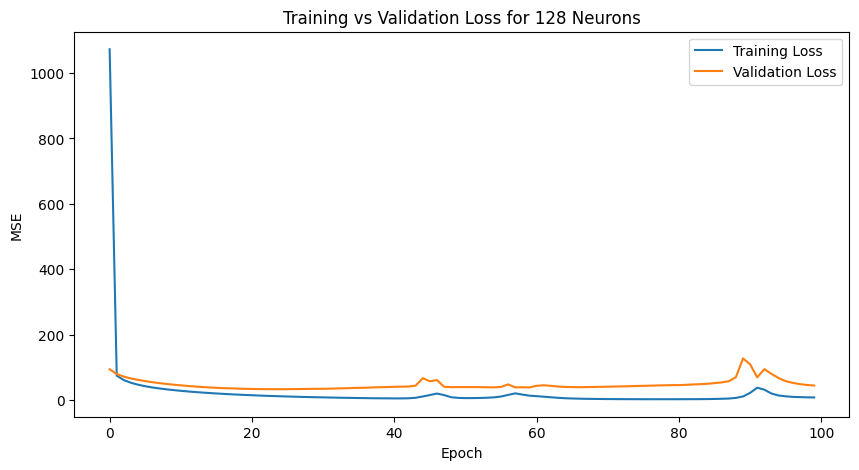


### Results for different neuron numbers

|   Variable |   Validation MSE |   Validation MAE |
|-----------:|-----------------:|-----------------:|
|          8 |          18.5305 |          3.39775 |
|         16 |          19.8287 |          3.51595 |
|         32 |          24.2176 |          3.85195 |
|         64 |          34.3625 |          4.74629 |
|        128 |          44.7789 |          5.28934 |

8 number of neurons had the best results with the lowest validation MSE of 18.530535 and validation MAE of 3.397751.


In [9]:
# Hardcoded depth_winner from creation and testing now happens at end of the hidden layer loop.
# Depth_winner = 3
# Depth_winner = results_df.loc[results_df["Validation MSE"].idxmin()]["Variable"]

# Array of different numbers of neurons to test in the next loop.
num_neurons = [8, 16, 32, 64, 128]

# Setup Dataframe to store results for the current hyperparameter being tested.
results_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)
results_df = results_df.iloc[0:0]
results_df.loc[len(results_df)] = ['Number of Neurons', '', '']


# Run thhe Nerons Loop testing all the number of neurons.
for n in num_neurons:
    print(f"Training model with {n} number of neurons...")
    model = create_dynamic_model(num_hidden_layers=depth_winner , num_neurons=n, activation_choice='relu', optimizer_choice='adam')
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        batch_size=32,
        verbose=1
    )
    val_loss, val_mae = model.evaluate(
        X_val_scaled, 
        y_val, 
        verbose=0
    )
    # Print the validation MSE and MAE for the current number of neurons.
    print(f"Validation MSE for {n} neurons: {val_loss}")
    print(f"Validation MAE for {n} neurons: {val_mae}")
    
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {n} Neurons")
    plt.legend()
    plt.show()
    results_df.loc[len(results_df)] = [n, val_loss, val_mae]
# Add current results to the total results dataframe.
results_total =pd.concat([results_total, results_df], ignore_index=True)
#print("Results for different neuron numbers:")
#print(results_df)

# Print the table of results for differnent neuron numbers in markup.
# Ignore the title row
numeric_rows = results_df[pd.to_numeric(results_df["Validation MSE"], errors="coerce").notna()]

best_row = numeric_rows.loc[numeric_rows["Validation MSE"].idxmin()]

markdown_text = f"""
### Results for different neuron numbers

{numeric_rows.to_markdown(index=False)}

{int(best_row['Variable'])} number of neurons had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))

# Assign the neurons_winner variable.
neurons_winner = int(
    numeric_rows.loc[
        numeric_rows["Validation MSE"].idxmin(),
        "Variable"
    ]
)

---
### Activation funtion Loop

---

Training model with relu activation function...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3953.4124 - mae: 62.1374 - val_loss: 3734.3354 - val_mae: 60.2788
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3090.8145 - mae: 54.4321 - val_loss: 2046.5519 - val_mae: 43.3956
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1005.5836 - mae: 27.4376 - val_loss: 445.3387 - val_mae: 17.3028
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 330.2674 - mae: 14.5683 - val_loss: 251.6163 - val_mae: 12.6952
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 225.9612 - mae: 12.0439 - val_loss: 195.8152 - val_mae: 11.2492
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 185.5985 - mae: 10.9553 - val_loss: 170.2017 - val_mae: 10.4940
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 162.2177 - mae: 10.2762 - val_loss: 153.6439 - val_mae: 9.9535
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 145.3828 - mae: 9.7352 - val_loss: 140.7241 - val_mae: 9.5036
Epoch 9/10

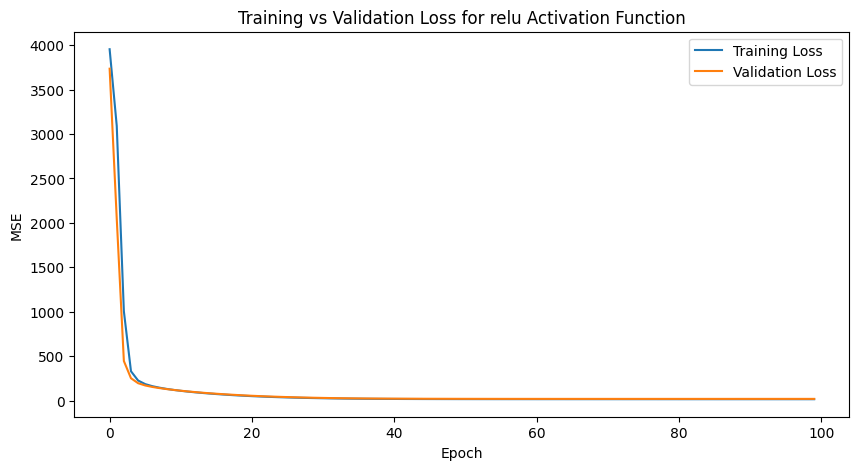

Training model with leaky_relu activation function...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3844.2371 - mae: 61.2305 - val_loss: 3463.2920 - val_mae: 57.9567
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2587.2561 - mae: 49.1218 - val_loss: 1400.1049 - val_mae: 34.3255
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 728.2394 - mae: 22.9417 - val_loss: 346.2000 - val_mae: 15.2712
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 259.4351 - mae: 12.9764 - val_loss: 222.9196 - val_mae: 12.1829
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 189.3823 - mae: 11.1299 - val_loss: 191.5672 - val_mae: 11.3428
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 163.0739 - mae: 10.3116 - val_loss: 174.5632 - val_mae: 10.8225
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 146.6243 - mae: 9.7843 - val_loss: 161.6829 - val_mae: 10.4057
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 133.8122 - mae: 9.3557 - val_loss: 150.5845 - val_mae: 10.0210
Epoch 9/10

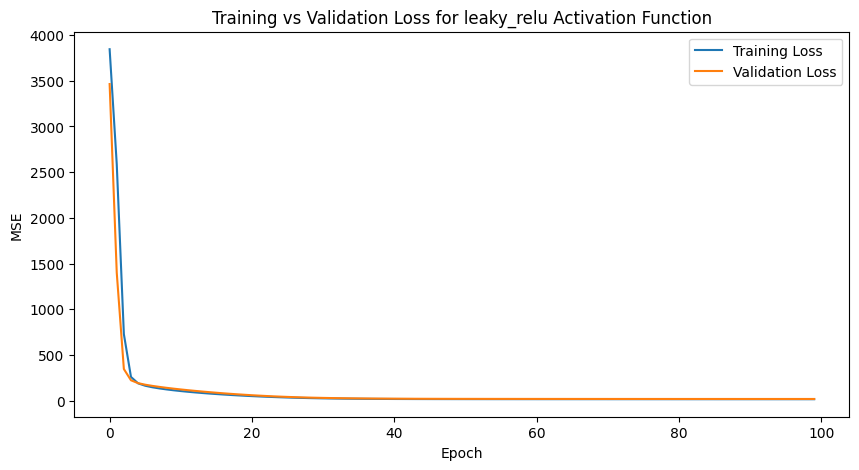

Training model with tanh activation function...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4006.8145 - mae: 62.5955 - val_loss: 3903.4443 - val_mae: 61.7184
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3743.1274 - mae: 60.4612 - val_loss: 3515.5117 - val_mae: 58.4814
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3352.5874 - mae: 57.1123 - val_loss: 3208.6113 - val_mae: 55.7720
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3125.0051 - mae: 55.0760 - val_loss: 3035.1626 - val_mae: 54.1898
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2974.5840 - mae: 53.6915 - val_loss: 2900.0984 - val_mae: 52.9274
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2847.9094 - mae: 52.4980 - val_loss: 2780.3943 - val_mae: 51.7835
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2732.7456 - mae: 51.3891 - val_loss: 2669.6550 - val_mae: 50.7026
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2625.0483 - mae: 50.3302 - val_loss: 2565.2700 - val_mae: 49.6

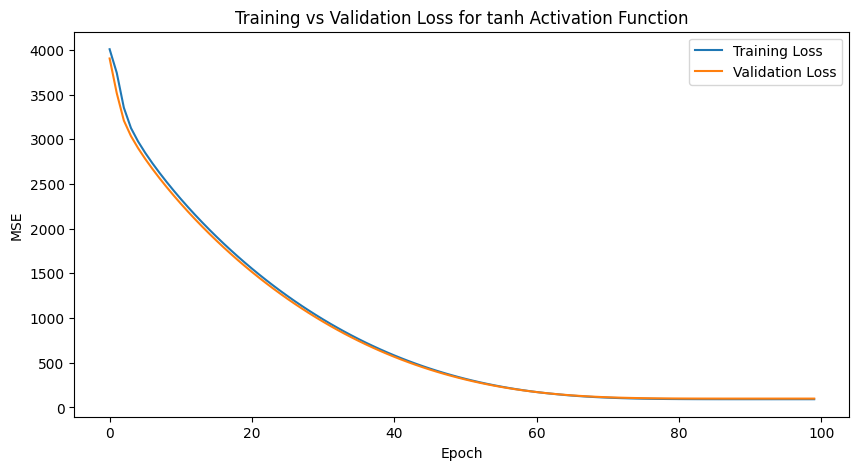

Training model with elu activation function...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3993.0959 - mae: 62.4460 - val_loss: 3840.4570 - val_mae: 61.1445
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3505.4553 - mae: 58.3367 - val_loss: 2926.5046 - val_mae: 53.1040
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1954.4791 - mae: 42.2969 - val_loss: 847.2521 - val_mae: 26.8467
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 377.4606 - mae: 16.3162 - val_loss: 200.1192 - val_mae: 11.4064
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 175.9832 - mae: 10.7951 - val_loss: 161.2598 - val_mae: 10.2169
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 145.2595 - mae: 9.7786 - val_loss: 137.8664 - val_mae: 9.4418
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 124.2349 - mae: 9.0184 - val_loss: 119.3744 - val_mae: 8.7723
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 107.4830 - mae: 8.3602 - val_loss: 104.0758 - val_mae: 8.1681
Epoch 9/100
1

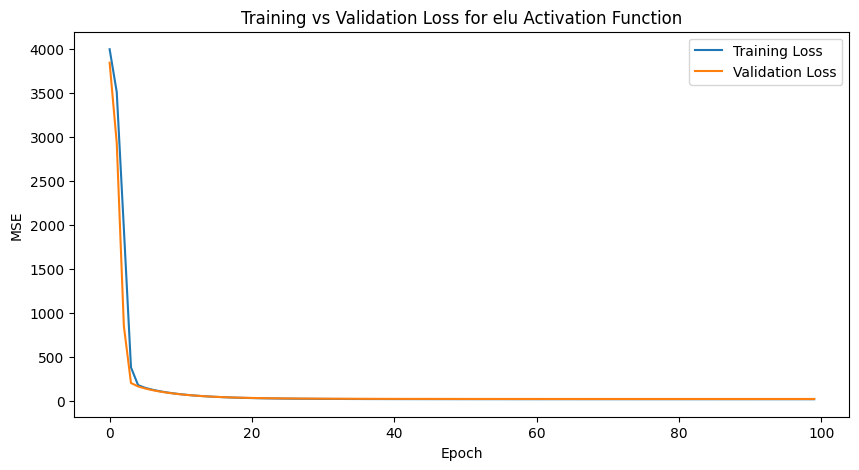

Training model with swish activation function...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4001.8608 - mae: 62.5062 - val_loss: 3876.8650 - val_mae: 61.4366
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3496.4409 - mae: 58.2391 - val_loss: 2744.1841 - val_mae: 51.2115
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1496.2509 - mae: 34.9209 - val_loss: 600.5081 - val_mae: 20.2214
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 429.0405 - mae: 16.6067 - val_loss: 359.3209 - val_mae: 15.2802
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 297.3597 - mae: 13.8380 - val_loss: 294.8241 - val_mae: 13.9370
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 246.1469 - mae: 12.6762 - val_loss: 259.8777 - val_mae: 13.1493
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 214.2437 - mae: 11.8630 - val_loss: 232.8236 - val_mae: 12.4621
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 189.6481 - mae: 11.1739 - val_loss: 209.7956 - val_mae: 11.8306
Epoch 9

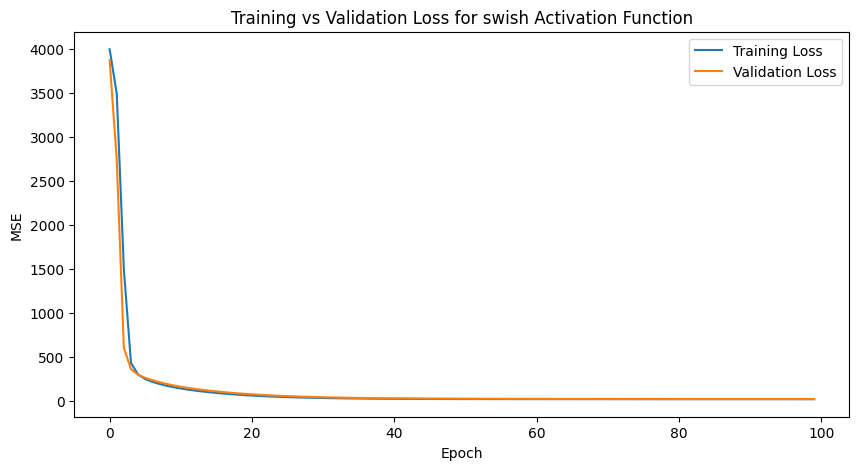


### Results for different activation functions

| Variable   |   Validation MSE |   Validation MAE |
|:-----------|-----------------:|-----------------:|
| relu       |          19.3164 |          3.4336  |
| leaky_relu |          18.4566 |          3.39283 |
| tanh       |          99.0067 |          7.82743 |
| elu        |          18.7282 |          3.40137 |
| swish      |          18.9928 |          3.44721 |

leaky_relu activation function had the best results with the lowest validation MSE of 18.456573 and validation MAE of 3.392829.


leaky_relu


In [10]:
#neurons_winner = 8

# Setup activation function array and results dataframe for the next loop.
activation_array = ['relu', 'leaky_relu','tanh','elu','swish']

# Setup Dataframe to store results for the activation function being tested.
results_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)
results_df.loc[len(results_df)] = ['Activation Function', '', '']


#Run the Activation Function Loop testing all the activation functions.
for a in activation_array:
    print(f"Training model with {a} activation function...")
    model = create_dynamic_model(num_hidden_layers=depth_winner , num_neurons=neurons_winner, activation_choice=a, optimizer_choice='adam')
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        batch_size=32,
        verbose=1
    )
    
    val_loss, val_mae = model.evaluate(
        X_val_scaled, 
        y_val, 
        verbose=0
    )
    # Print the validation MSE and MAE for the current activation function.
    print(f"Validation MSE for {a} activation function: {val_loss}")
    print(f"Validation MAE for {a} activation function: {val_mae}")
        # Plot the training and validation loss for the current activation function.
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {a} Activation Function")
    plt.legend()
    plt.show()
    # Add row to results dataframe.
    results_df.loc[len(results_df)] = [a, val_loss, val_mae]
results_total =pd.concat([results_total, results_df], ignore_index=True)
#print("Results for different activation functions:")
#print(results_df)

#Dropping int from best_row['Variable'] to avoid error with LeakyReLU
# Ignore the title row
numeric_rows = results_df[pd.to_numeric(results_df["Validation MSE"], errors="coerce").notna()]
# Display the new dataframe for activation functions in markup.
best_row = numeric_rows.loc[numeric_rows["Validation MSE"].idxmin()]

markdown_text = f"""
### Results for different activation functions

{numeric_rows.to_markdown(index=False)}

{(best_row['Variable'])} activation function had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))

# Declare the activation_winner variable to store the best activation function based on the lowest validation MSE.
activation_winner = numeric_rows.loc[
    numeric_rows["Validation MSE"].idxmin(),
    "Variable"
]

print(activation_winner)

---
### Optimizer Array Loop.

---

Training model with adam optimizer...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3892.5913 - mae: 61.6015 - val_loss: 3612.9214 - val_mae: 59.1634
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2911.8970 - mae: 52.3477 - val_loss: 1774.1892 - val_mae: 39.2394
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 913.0276 - mae: 25.4877 - val_loss: 429.2115 - val_mae: 16.7974
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 331.0824 - mae: 14.5204 - val_loss: 275.4975 - val_mae: 13.5338
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 233.5918 - mae: 12.1910 - val_loss: 225.2872 - val_mae: 12.2443
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 192.4285 - mae: 11.0926 - val_loss: 195.8436 - val_mae: 11.3768
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 166.2194 - mae: 10.3087 - val_loss: 173.9418 - val_mae: 10.6907
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 146.2799 - mae: 9.6731 - val_loss: 155.4945 - val_mae: 10.0771
Epoch 9/1

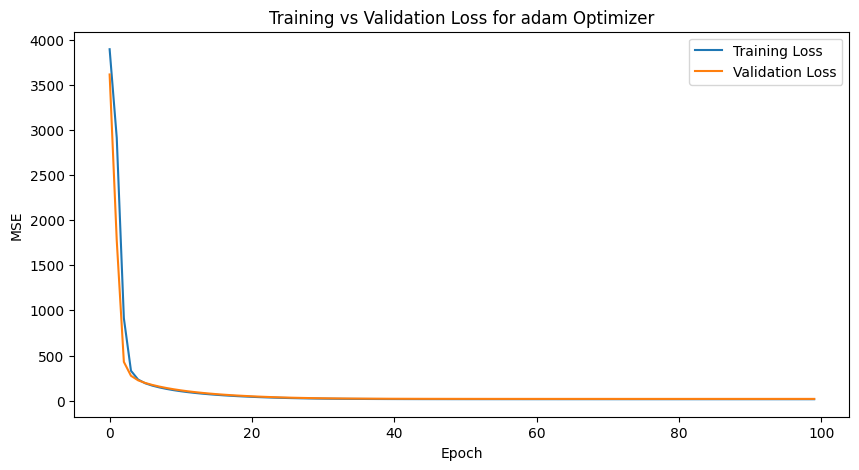

Training model with adamax optimizer...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4074.9038 - mae: 63.1073 - val_loss: 3994.7996 - val_mae: 62.4129
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3926.4861 - mae: 61.9149 - val_loss: 3806.6963 - val_mae: 60.8859
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3663.0071 - mae: 59.7282 - val_loss: 3444.6304 - val_mae: 57.8139
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3195.9058 - mae: 55.5954 - val_loss: 2852.5911 - val_mae: 52.3217
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2492.7319 - mae: 48.5698 - val_loss: 2033.6405 - val_mae: 43.3337
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1608.9690 - mae: 37.6395 - val_loss: 1142.9463 - val_mae: 30.7072
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 820.7942 - mae: 24.8543 - val_loss: 563.7355 - val_mae: 19.9402
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 430.7791 - mae: 17.0264 - val_loss: 359.0737 - val_mae: 15.1656


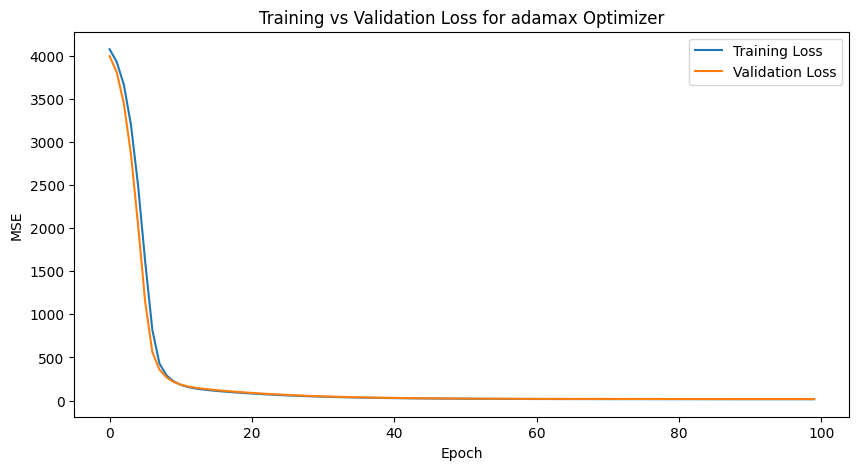

Training model with nadam optimizer...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4075.9375 - mae: 63.1180 - val_loss: 4026.6233 - val_mae: 62.6754
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3950.4746 - mae: 62.1302 - val_loss: 3783.7607 - val_mae: 60.7416
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3415.3423 - mae: 57.6714 - val_loss: 2705.5945 - val_mae: 51.1309
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1654.8986 - mae: 38.0209 - val_loss: 689.4031 - val_mae: 22.5464
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 416.7676 - mae: 16.6152 - val_loss: 290.5780 - val_mae: 13.8746
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 227.1247 - mae: 12.1587 - val_loss: 209.5847 - val_mae: 11.5787
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 179.9643 - mae: 10.8124 - val_loss: 179.2964 - val_mae: 10.6874
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 157.2308 - mae: 10.1011 - val_loss: 161.4148 - val_mae: 10.1471
Epoch

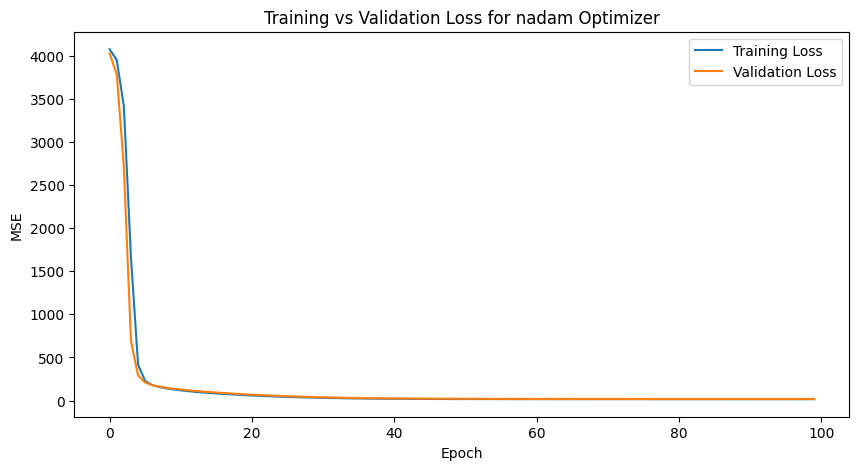

Training model with rmsprop optimizer...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4043.2505 - mae: 62.8604 - val_loss: 3967.3977 - val_mae: 62.2019
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3857.1946 - mae: 61.3736 - val_loss: 3664.8770 - val_mae: 59.7464
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3381.7549 - mae: 57.3860 - val_loss: 2957.2590 - val_mae: 53.5463
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2421.9160 - mae: 48.1622 - val_loss: 1739.9960 - val_mae: 40.3647
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1131.2976 - mae: 31.0689 - val_loss: 555.4311 - val_mae: 20.1475
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 369.3572 - mae: 15.7693 - val_loss: 269.8641 - val_mae: 13.2750
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 224.6788 - mae: 12.0455 - val_loss: 196.4800 - val_mae: 11.2758
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 167.0806 - mae: 10.3880 - val_loss: 157.0237 - val_mae: 10.1188
Epo

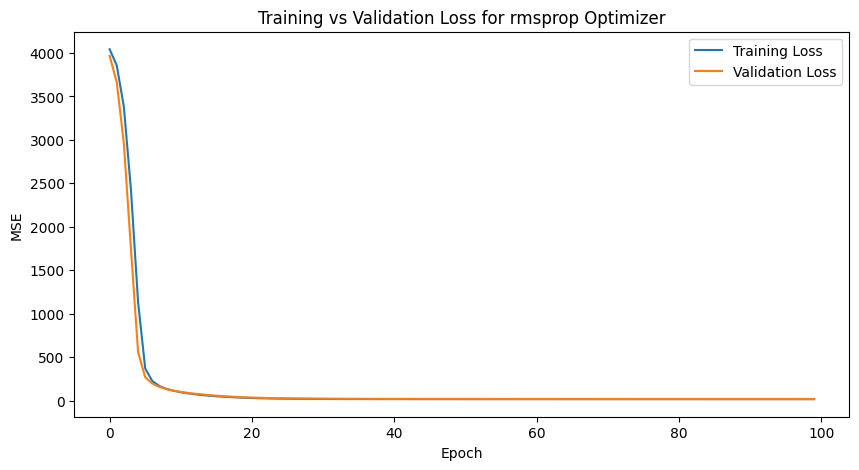

Training model with sgd optimizer...
Epoch 1/100


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

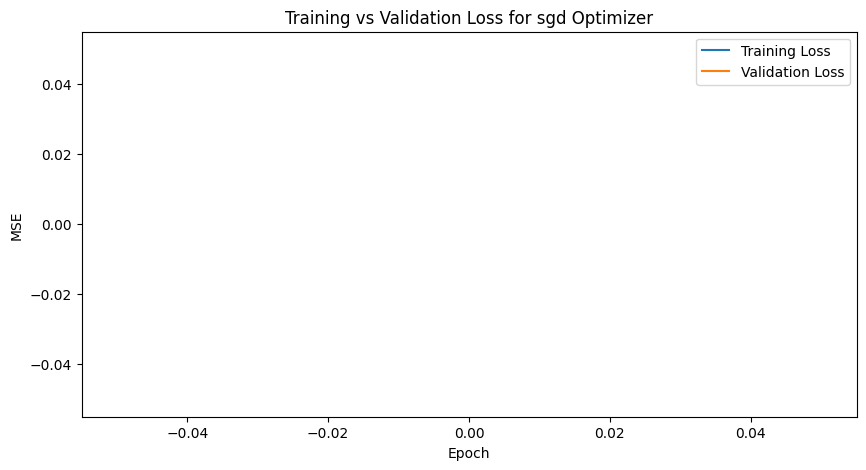


### Results for different Optimizers

| Variable   |   Validation MSE |   Validation MAE |
|:-----------|-----------------:|-----------------:|
| adam       |          19.4149 |          3.44421 |
| adamax     |          18.5158 |          3.37498 |
| nadam      |          18.9659 |          3.42727 |
| rmsprop    |          18.8198 |          3.40359 |

adamax Optimizer had the best results with the lowest validation MSE of 18.515764 and validation MAE of 3.374981.


In [11]:
#activation_winner = 'leaky_relu' now done automatically earlier in the code after the activation function loop.

# Optimizer Array.
optimizer_choice = ['adam', 'adamax', 'nadam', 'rmsprop', 'sgd']

# Setup Dataframe to store results for the optimizer being tested.
results_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)
results_df.loc[len(results_df)] = ['Optimizer', '', '']

# Run the Optimizer Loop testing all the optimizers.
for o in optimizer_choice:
    print(f"Training model with {o} optimizer...")
    model = create_dynamic_model(num_hidden_layers=depth_winner , num_neurons=neurons_winner, activation_choice=activation_winner, optimizer_choice=o)
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        batch_size=32,
        verbose=1   
    )
    
    val_loss, val_mae = model.evaluate(
        X_val_scaled, 
        y_val, 
        verbose=0
    )

    print(f"Validation MSE for {o} optimizer: {val_loss}")
    print(f"Validation MAE for {o} optimizer: {val_mae}")
    #Print the plot
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {o} Optimizer")
    plt.legend()
    plt.show()
    results_df.loc[len(results_df)] = [o, val_loss, val_mae]

 # add current results to the total results dataframe.   
results_total =pd.concat([results_total, results_df], ignore_index=True)
#print("Results for different optimizers:")
#print(results_df)




# Print the table of results for differnent optimizers in markup.

numeric_rows = results_df[pd.to_numeric(results_df["Validation MSE"], errors="coerce").notna()]

best_row = numeric_rows.loc[numeric_rows["Validation MSE"].idxmin()]

markdown_text = f"""
### Results for different Optimizers

{numeric_rows.to_markdown(index=False)}

{(best_row['Variable'])} Optimizer had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))
optimizer_winner = numeric_rows.loc[
    numeric_rows["Validation MSE"].idxmin(),
    "Variable"
]

---
### Print results_total dataframe in html table

---

In [14]:

# Print the final results table for all hyperparameter combinations in markup.

from IPython.display import display, HTML
display(HTML(results_total.to_html(index=False)))

print("Best model configuration:")
print(f"Number of hidden layers: {depth_winner}")
print(f"Number of neurons: {neurons_winner}")
print(f"Activation function: {activation_winner}")
print(f"Optimizer: {optimizer_winner}")





Variable,Validation MSE,Validation MAE
Hidden Layers Depth,,
1.0,24.694969,3.923995
2.0,25.377497,4.016453
3.0,23.468645,3.813957
4.0,26.956209,4.065215
Number of Neurons,,
8.0,18.530535,3.397751
16.0,19.828676,3.515946
32.0,24.217588,3.851948
64.0,34.362488,4.746291


Best model configuration:
Number of hidden layers: 3
Number of neurons: 8
Activation function: leaky_relu
Optimizer: adamax


---
## Create Dropout Model for dropout testing
---

In [15]:
# Create a new function for the dropout testing model. This function is similar to the previous one but includes a dropout layer after each hidden layer. The dropout rate can be specified as an argument, allowing for experimentation with different dropout rates to prevent overfitting.
def create_dynamic_model_dropout(
    num_hidden_layers,
    num_neurons,
    activation_choice,
    optimizer_choice,
    dropout_rate=0.0
):

    model = Sequential()

    # First layer
    model.add(Dense(num_neurons,
                    input_shape=(X_train_scaled.shape[1],)))

    if activation_choice == 'leaky_relu':
        model.add(LeakyReLU(negative_slope=0.01))
    else:
        model.add(Activation(activation_choice))

    model.add(Dropout(dropout_rate))

    # Remaining hidden layers
    for _ in range(num_hidden_layers - 1):

        model.add(Dense(num_neurons))

        if activation_choice == 'leaky_relu':
            model.add(LeakyReLU(negative_slope=0.01))
        else:
            model.add(Activation(activation_choice))

        model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer=optimizer_choice,
        loss='mse',
        metrics=['mae']
    )

    return model

---
### Test Dropout rate

---

Training model with dropout=0.0


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with dropout=0.1


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with dropout=0.2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with dropout=0.3


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with dropout=0.4


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


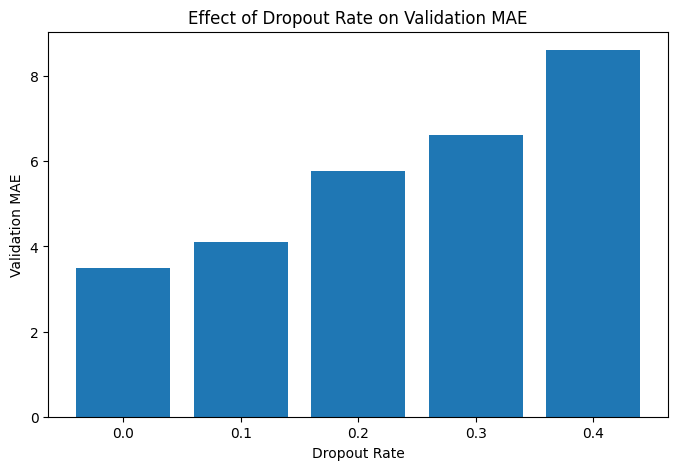


### Results for different Dropout Rates

|   Variable |   Validation MSE |   Validation MAE |
|-----------:|-----------------:|-----------------:|
|        0   |          19.5509 |          3.49497 |
|        0.1 |          26.2289 |          4.10464 |
|        0.2 |          48.2507 |          5.77609 |
|        0.3 |          62.1064 |          6.61691 |
|        0.4 |         100.715  |          8.61616 |

0.0 Dropout rate had the best results with the lowest validation MSE of 19.550922 and validation MAE of 3.494974.


In [16]:
# Drop out rates array
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4]
# Clear Dataframe to store results for the current hyperparameter being tested.
results_df = pd.DataFrame(
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)
depth_winner = 3
neurons_winner = 8
activation_winner = 'leaky_relu'
optimizer_winner = 'adamax'
for d in dropout_rates:

    print(f"Training model with dropout={d}")

    model = create_dynamic_model_dropout(
        num_hidden_layers=depth_winner,
        num_neurons=neurons_winner,
        activation_choice=activation_winner,
        optimizer_choice=optimizer_winner,
        dropout_rate=d
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        batch_size=32,
        verbose=0
    )

    val_loss, val_mae = model.evaluate(
        X_val_scaled,
        y_val,
        verbose=0
    )

    results_df.loc[len(results_df)] = [d, val_loss, val_mae]


results_total =pd.concat([results_total, results_df], ignore_index=True)
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Variable"].astype(str),
    results_df["Validation MAE"]
)

plt.xlabel("Dropout Rate")
plt.ylabel("Validation MAE")
plt.title("Effect of Dropout Rate on Validation MAE")

plt.show()
# Movin this causes issues somethimes
from IPython.display import HTML, display


# Ignore the title row
numeric_rows = results_df[pd.to_numeric(results_df["Validation MSE"], errors="coerce").notna()]

best_row = numeric_rows.loc[numeric_rows["Validation MSE"].idxmin()]

markdown_text = f"""
### Results for different Dropout Rates

{numeric_rows.to_markdown(index=False)}

{(best_row['Variable'])} Dropout rate had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))
dropout_winner = numeric_rows.loc[
    numeric_rows["Validation MSE"].idxmin(),
    "Variable"
]




---
Dropout regularisation was evaluated using rates between 0.0 and 0.4.
The lowest validation rate was obtained with 0.0 suggesting the selected network architechture was small enough that dropout introduced underfitting rather than overfitting.

---

---
### Display the complete tabe and the final set of Hyperparams.

---

In [17]:
display(HTML(results_total.to_html(index=False)))



summary_df = pd.DataFrame({
    "Hyperparameter": [
        "Hidden Layers",
        "Neurons",
        "Activation Function",
        "Optimizer",
        "Dropout Rate"
    ],
    "Best Value": [
        depth_winner,
        neurons_winner,
        activation_winner,
        optimizer_winner,
        dropout_winner
    ]
})

display(summary_df)

Variable,Validation MSE,Validation MAE
Hidden Layers Depth,,
1.0,24.694969,3.923995
2.0,25.377497,4.016453
3.0,23.468645,3.813957
4.0,26.956209,4.065215
Number of Neurons,,
8.0,18.530535,3.397751
16.0,19.828676,3.515946
32.0,24.217588,3.851948
64.0,34.362488,4.746291


,Hyperparameter,Best Value
0,Hidden Layers,3
1,Neurons,8
2,Activation Function,leaky_relu
3,Optimizer,adamax
4,Dropout Rate,0.0


---
## Create the final model

---

In [18]:
#Create the final model using the best hyperparameters found during the search.
final_model = create_dynamic_model_dropout(
    num_hidden_layers=3,
    num_neurons=8,
    activation_choice='leaky_relu',
    optimizer_choice='adamax',
    dropout_rate=0.0
)

C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:

#Train the final model with early stopping to prevent overfitting.

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4020.9509 - mae: 62.6834 - val_loss: 3950.3953 - val_mae: 62.0631
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3860.9390 - mae: 61.4054 - val_loss: 3722.4277 - val_mae: 60.2108
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3534.0139 - mae: 58.6947 - val_loss: 3282.6477 - val_mae: 56.4470
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2951.5771 - mae: 53.4695 - val_loss: 2549.8262 - val_mae: 49.4597
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2069.0491 - mae: 44.1439 - val_loss: 1542.2537 - val_mae: 37.4104
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1062.4626 - mae: 29.6679 - val_loss: 647.4620 - val_mae: 21.9768
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 469.2720 - mae: 18.0424 - val_loss: 342.6336 - val_mae: 15.1125
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 306.9543 - mae: 14.2433 - val_loss: 256.6486 - val_ma

In [20]:
#Evaluate the final model on the test set and print the results.
test_loss, test_mae = final_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Final Test MSE: {test_loss:.6f}")
print(f"Final Test MAE: {test_mae:.6f}")

Final Test MSE: 18.663485
Final Test MAE: 3.401093


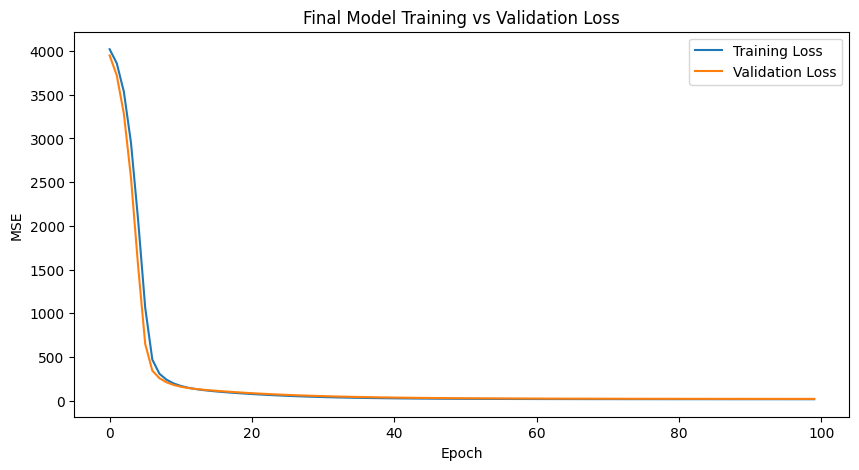

In [21]:
#Plot the training and validation loss for the final model.
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Final Model Training vs Validation Loss")
plt.legend()

plt.show()

---
#### Generate predictions on the test set and calculate the R² score to evaluate the final model's performance.

---

In [22]:
# Generate predictions 
y_pred = final_model.predict(X_test_scaled)

from sklearn.metrics import r2_score
# Calculate R² score
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
R² Score: 0.7974


---
### Final Results

---

In [23]:
final_results_df = pd.DataFrame({
    "Metric": ["Test MSE", "Test MAE", "R²"],
    "Value": [test_loss, test_mae, r2]
})

display(HTML(final_results_df.to_html(index=False)))

Metric,Value
Test MSE,18.663485
Test MAE,3.401093
R²,0.797421


---
### Export final model

---

In [24]:
# Export the final model to a file for later use or deployment.
final_model.save("soil_carbon_model.keras")


#### To load

from tensorflow.keras.models import load_model

model = load_model("soil_carbon_model.keras")



---
### Export Final Model Weights

---

In [25]:
# Export the model weights to a file for later use or deployment.
final_model.save_weights("soil_carbon_weights.weights.h5")

#### To load

model = create_dynamic_model_dropout(
    num_hidden_layers=3,
    num_neurons=8,
    activation_choice='leaky_relu',
    optimizer_choice='adamax',
    dropout_rate=0.0
)

model.load_weights("soil_carbon_weights.weights.h5")


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline predictions
baseline_pred = baseline_model.predict(X_test_scaled)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_pred)

# Final model predictions
final_pred = final_model.predict(X_test_scaled)

final_mae = mean_absolute_error(y_test, final_pred)
final_mse = mean_squared_error(y_test, final_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_pred)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [27]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Final"],
    "MAE": [baseline_mae, final_mae],
    "MSE": [baseline_mse, final_mse],
    "RMSE": [baseline_rmse, final_rmse],
    "R2": [baseline_r2, final_r2]
})

#display(comparison_df)
from IPython.display import Markdown, display

markdown_text = f"""
### Task 3.1 Model Interpretation and Critical Evaluation

{comparison_df.to_markdown(index=False)}
"""

display(Markdown(markdown_text))


### Task 3.1 Model Interpretation and Critical Evaluation

| Model    |     MAE |     MSE |    RMSE |       R2 |
|:---------|--------:|--------:|--------:|---------:|
| Baseline | 3.90569 | 23.8776 | 4.88647 | 0.740826 |
| Final    | 3.40109 | 18.6635 | 4.32013 | 0.797421 |


---
### Task 3.1 Model Interpretation and Critical evaluation

|Model|MAE|MSE|RSME|R2|
|---|---|---|---|---|
|Baseline|3.90569 |23.8776 | 4.88647|  0.740826|
|Final|3.40109| 18.6635|4.32013 |0.797421 |


The Final DNN outperformed the Baseline in all metrics

* MAE decreased  from 3.90569 to 3.40109.
    * Predictions were on average was more accurate.

* MSE decreased from 23.8776 to 18.6635.
    * Demonstrating a reduction in prediction errors.

* RMSE decreased from 4.88647 to 4.32013.
    * This suggests that the hyperparameter tuning reduced the size of prediction inaccuracues.

* R2 increased from 0.740826 to 0.797421
    * This indicates that the final model explains 79.74% of the varience in the target variable SOC.


Overall this demonstrates that the hyperparameter tuning resulted in a sizable (around 5%) improvement in performance.

The final model configuration was:

|Hyperparameter| Best Value|
|---|---|
|Hidden Layer|3|
|Neurons|8|
|Activation Function|Leaky ReLU|
|Optimiser|Adamax|
|Dropout Rate|0.0|


The number of neurons was a suprising result as I originally had only placed it the array to speed up testing with and array of [8,16] I spent a lot of time check that someting else was not wrong. With a larger dataset I may found that more neurons would have helped the performance.

However with the tools to hand the final model achieved a lower prediction error and higher explanatory power that the baseline model, demostrating the value of hyperparameter tuning.


---